# Copenhagen Burnout Inventory Validation

## 1 Overview

This notebook explores the relationship between the Solace wellbeing score and the Copenhagen Burnout Inventory (CBI), a published burnout assessment tool [1]. In order to obtain two completely independent measures of the same underlying state, each participant in the user-testing study completes the CBI questionnaire via a Google Form and separately provides a brief spoken recording. The questionnaire responses are scored separately from the recordings. Each participant's audio or video recording is processed through the corresponding Solace pipeline pathway. A legitimate wellbeing score should move in the opposite direction from the CBI burnout score as burnout and wellbeing are opposites, and the notebook measures precisely that.

Participants recorded in English, Malay, Chinese, or Tamil, and their recordings are arranged into video and audio folders specific to each language, making the study fully multilingual. Because the pipeline scores and transcribes each recording in its native tongue, the validation is not an English-only approximation but rather represents the actual multilingual use of the software. The comparison itself is done in two complementary ways a correlation between the two continuous scores and an agreement check between their discrete risk bands. This is because the first indicates the direction and strength of the relationship, while the second indicates the decision that the application actually presents to a user.

Instead of being a synthetic rehearsal, this is a real-data validation since it rates the genuine recordings and reads the real questionnaire responses. The results should be interpreted as authentic but preliminary external evidence because the participant sample is inherently small for a final-year project and recruitment may still be ongoing. The direction and band agreement are the significant outcomes, and given the sample size, precise correlation magnitudes should be handled with caution.

## 2 Importing Libraries

This section imports the small, focused toolchain the validation depends on. pandas and NumPy structure the questionnaire responses, the recording index and the results tables. statistics.mean computes the CBI sub-scores in a way that mirrors the official scoring scheme and scikit-learn supplies the two comparison tools used later accuracy for the overall band agreement and a confusion matrix for its per-band breakdown. Sys is imported so that the project root may be added to the path in the following phase, allowing the Solace pipeline to be imported like any installed package, while matplotlib creates the agreement heatmap and scatter plot.

In [1]:
# remove all warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
# import required libraries
from pathlib import Path
from statistics import mean
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix

Because this notebook orchestrates pre-existing components rather than training anything, the dependency list is purposefully minimal. It calls the deployed Solace pipeline, scores a questionnaire, and compares the two. For a result that will be cited as external evidence in the report, it is important to keep the imports clear and upfront so that the validation runs exactly the same each time it is re-executed. The Solace pipeline itself is made importable in the following section.

## 3 Load Solace Pipeline

This component loads the multimodal pipeline and allows the application's own code to be imported from within the notebook. The MultimodalPipeline class, which is precisely the same object that the live application uses to score a recording, is then imported and instantiated once the project root, which is two levels up from the notebook, is placed onto the Python path. Since the primary purpose of the validation is to verify the deployed scorer, not an approximation of it, loading the actual pipeline rather than re-implementing it is important.

In [3]:
# project root
PROJECT_ROOT = Path.cwd().parents[1]

In [4]:
# if project root not in path
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [5]:
# import MultimodalPipeline
from UI.ai.multimodal_pipeline import MultimodalPipeline

In [6]:
# get pipeline
pipeline = MultimodalPipeline()

In [7]:
# print statements
print("Project root:", PROJECT_ROOT)
print("Solace pipeline loaded")

Project root: c:\Users\Subathra\OneDrive\Desktop\CM3020_Solace_Wellbeing_Monitoring\CM3020_Solace_Wellbeing_Monitoring_FYP
Solace pipeline loaded


The validation's weight comes from using the production pipeline directly, which ensures that any conclusions made here apply to the system that users actually interact with. The pipeline and its underlying models loaded successfully, according to the printed confirmation. The following section fixes the research settings, including the location of the data, the languages covered, and the band thresholds for both instruments, once the scorer is accessible.

## 4 Study Settings

The location of the output questionnaire CSV, the root folder of the user-testing recordings, the four supported languages, the media file extensions to search for, and the numerical band thresholds for both instruments are all gathered in this section. Both the root and the language list are required to find a participant's files because the recordings are located under a User Testing/Recordings folder that is divided by language and modality, with a Video and an Audio folder for each language. The Solace wellbeing cut-offs (high at 67, mixed at 34) match the bands the application itself uses, while the CBI cut-offs (high at 75, moderate at 50) adhere to standard CBI reporting practices. As a result, the two systems are compared based on the words they were created around.

In [8]:
# response file
RESPONSES_FILE = PROJECT_ROOT / "User_testing" / "Wellbeing_Check.csv"

In [9]:
# recording directory
RECORDINGS_DIR = PROJECT_ROOT / "User_testing" / "Recordings"

In [10]:
# define languages list
LANGUAGES = ["English", "Malay", "Chinese", "Tamil"]

In [11]:
# define video extensions list
VIDEO_EXTENSIONS = [".mp4", ".mov", ".mkv", ".avi", ".webm", ".m4v"]

In [12]:
# define audio extension list
AUDIO_EXTENSIONS = [".wav", ".mp3", ".m4a", ".aac", ".flac", ".ogg"]

In [13]:
# scores
CBI_HIGH = 75
CBI_MODERATE = 50
WELLBEING_HIGH = 67
WELLBEING_MIXED = 34

In [14]:
# print statments
print("Responses file:", RESPONSES_FILE)
print("Recordings folder:", RECORDINGS_DIR)

Responses file: c:\Users\Subathra\OneDrive\Desktop\CM3020_Solace_Wellbeing_Monitoring\CM3020_Solace_Wellbeing_Monitoring_FYP\User_testing\Wellbeing_Check.csv
Recordings folder: c:\Users\Subathra\OneDrive\Desktop\CM3020_Solace_Wellbeing_Monitoring\CM3020_Solace_Wellbeing_Monitoring_FYP\User_testing\Recordings


The pathways, languages, and thresholds are centralised here, which removes magic numbers from the rest of the notebook and makes it simple to extend or repoint the study moving the data or adding a language only requires a single line. Additionally, the recording search becomes robust regardless of the format in which the recordings were saved by explicitly defining the allowed extensions. The process for converting a raw CBI questionnaire into a score is described in the next section.

## 5 CBI Scoring

In order to make the burnout figure an accurate CBI value rather than an ad hoc sum, this part applies the official CBI scoring scheme. The main routine determines the participant column, treats the remaining question columns as the 13 CBI items in order, and averages the six personal-burnout items and the seven work items separately as well as overall. A lookup table converts each verbal response option to its standard point value from 0 to 100. A helper maps any single response, tolerating whitespace and the multiple wording variations of the lowest option, to those points. The energy question, which is the last item, is crucially reverse-scored since it shows less burnout rather than more when people report having more energy for friends and family [1].

In [15]:
# define response points
RESPONSE_POINTS = {
    "always": 100,
    "to a very high degree": 100,
    "often": 75,
    "to a high degree": 75,
    "sometimes": 50,
    "somewhat": 50,
    "seldom": 25,
    "to a low degree": 25,
    "to a very low degree": 0
}

In [16]:
# personal and work count
PERSONAL_COUNT = 6
WORK_COUNT = 7

In [17]:
# define response points
def response_points(value):
    # set key
    key = " ".join(str(value).strip().lower().split())
    if key in RESPONSE_POINTS:
        # return response points
        return RESPONSE_POINTS[key]
    if key.startswith("never"):
        return 0
    # raise ValueError
    raise ValueError(f"Unrecognised response: {value!r}")

In [18]:
# define score sbi
def score_cbi(form_df):
    # columns
    columns = list(form_df.columns)
    # participant column
    participant_column = next(column for column in columns if "participant" in column.lower())
    # build item columns list
    item_columns = [column for column in columns if column != participant_column and "timestamp" not in column.lower() and form_df[column].notna().any()]
    item_columns = item_columns[: PERSONAL_COUNT + WORK_COUNT]
    # set personal items
    personal_items = item_columns[:PERSONAL_COUNT]
    # set work items
    work_items = item_columns[PERSONAL_COUNT:]
    # set reverse item
    reverse_item = item_columns[-1]
    # define rows list
    rows = []
    for _, row in form_df.iterrows():
        # build points mapping
        points = {column: response_points(row[column]) for column in item_columns}
        points[reverse_item] = 100 - points[reverse_item]
        personal_score = mean(points[c] for c in personal_items)
        work_score = mean(points[c] for c in work_items)
        overall_score = mean(points[c] for c in item_columns)
        participant_id = str(row[participant_column]).strip()
        # row append to list
        rows.append({
            "participant_id": participant_id,
            "personal_burnout": personal_score,
            "work_burnout": work_score,
            "cbi_score": overall_score
        })
    return pd.DataFrame(rows)

The comparison versus Solace is legitimate since CBI scoring is implemented formally rather than relying on an ad hoc sum for the validation to have any significance, the burnout figure must be a valid CBI score. The type of silent scoring error that would gradually corrupt every downstream result is prevented by handling the response-wording variations and the reverse item conservatively. Additionally, raising on any unrecognised answer ensures that a mistyped export is detected right away rather than being mis-scored. The actual responses can be loaded and scored once the scoring has been established.

## 6 Load and Score CBI Responses

This phase creates a personal, job, and overall CBI burnout score for each participant by reading the exported questionnaire CSV and running it through the scoring process. By reading straight from the actual output, the validation's burnout component is calculated using only real participant responses there are no fake stand-ins in the notebook.

In [19]:
# read CSV file
form_df = pd.read_csv(RESPONSES_FILE)
# response dataframe
responses_df = score_cbi(form_df)
# print statements
print("Participants scored:", len(responses_df))
responses_df.round(2)

Participants scored: 16


,participant_id,personal_burnout,work_burnout,cbi_score
0,P012,70.83,67.86,69.23
1,P08,41.67,32.14,36.54
2,P09,54.17,50.00,51.92
3,P01,50.00,50.00,50.00
4,P07,79.17,67.86,73.08
5,P02,58.33,82.14,71.15
6,P010,54.17,21.43,36.54
7,P03,58.33,57.14,57.69
8,P011,50.00,57.14,53.85
9,P05,79.17,57.14,67.31


**Analysis:** 

Each participant's personal burnout, job burnout, and overall CBI score are shown in the above table. These scores were calculated directly from their questionnaire responses using the official system, with the energy item being reverse-scored. The precise group of participants and their scores will increase as more responses come in because the study's recruitment may still be ongoing. What is fixed and crucial in this situation is that the scoring accurately replicates the CBI, so each value is a legitimate burnout score that can be compared to an independent Solace score. Since a sample crowded at one extreme would leave nothing to correlate against, the distribution of scores over the low-to-high burnout range is what allows for a meaningful correlation and band comparison later. Now that each participant's burnout score has been obtained, the notebook must locate each participant's recording in order to obtain the corresponding Solace wellbeing score.

## 7 Locate Participant Recordings

This section connects the participant IDs from the questionnaire to the recordings in the language specific video and audio folders. A participant can be highlighted with video or audio only recording. If both are available, the video is selected such that each participant produces one result. The file names should correspond to the questionnaire participants IDs

In [20]:
# define id variants
def _id_variants(participant_id):
    # text
    text = str(participant_id).strip()
    # define variants
    variants = {text}
    # compute digits
    digits = "".join(character for character in text if character.isdigit())
    if digits:
        # update dict
        variants.update({digits, "P" + digits, "P" + digits.zfill(2), "P" + digits.zfill(3)})
    return {variant.lower() for variant in variants}

In [21]:
# define find in folder
def _find_in_folder(folder, participant_id, extensions):
    if not folder.is_dir():
        return None
    # wanted id
    wanted = _id_variants(participant_id)
    for file in sorted(folder.iterdir()):
        # if suffix in extensions
        if file.suffix.lower() in extensions and file.stem.strip().lower() in wanted:
            return file
    return None

In [22]:
# Find either video or audio for each participant
def find_recordings(participant_id):
    for language in LANGUAGES:
        # video and audio folder
        video = _find_in_folder(RECORDINGS_DIR / f"{language}_Video",participant_id,VIDEO_EXTENSIONS)
        audio = _find_in_folder(RECORDINGS_DIR / f"{language}_Audio",participant_id,AUDIO_EXTENSIONS)
        # return the results
        if video is not None or audio is not None:
            return language, video, audio

    return None, None, None

In [23]:
# define recording index
recording_index = {}
# define coverage rows list
coverage_rows = []

In [24]:
for participant_id in responses_df["participant_id"]:
    # language, video path and audio path
    language, video_path, audio_path = find_recordings(participant_id)
    recording_index[participant_id] = (language, video_path, audio_path)
    # =coverage rows append to the list
    coverage_rows.append({
        "participant_id": participant_id,
        "language": language if language else "NOT FOUND",
        "video": video_path.name if video_path else "-",
        "audio": audio_path.name if audio_path else "-",
    })

In [25]:
# build coverage dataframe
coverage_df = pd.DataFrame(coverage_rows)
coverage_df

,participant_id,language,video,audio
0,P012,English,P012.mp4,-
1,P08,English,P08.mp4,-
2,P09,English,P09.MOV,-
3,P01,English,-,P01.ogg
4,P07,English,-,P07.m4a
5,P02,Tamil,-,P02.m4a
6,P010,English,-,P010.m4a
7,P03,Tamil,-,P03.ogg
8,P011,Tamil,P011.mp4,-
9,P05,Chinese,P05.mp4,-


**Analysis:** 

An honest map of the study's completeness can be found in the coverage table above, which either flags a participant as not discovered or displays the language in which their recording was found along with the precise video and audio files that matched. In order to ensure that the validation is never subtly altered by a missing file, every participant who is marked NOT FOUND has a questionnaire but no locatable recording and will simply be excluded from the matched comparison. The fastest way to identify a mislabeled recording for example, a participant typed 9 on the form but saved as P09 while there is still time to rename it is to check this table before scoring. It also verifies the linguistic distribution of the recordings that are truly being validated. The notebook may now generate each participant's Solace wellbeing score as each one is connected to their recording and language.

## 8 Score Recordings with Solace

Each matched recording is processed using the application’s pipeline.analyse() method.  Video recordings are processed by the video pathway including audio extracted from the video, while audio-only recordings are processed by the audio pathway, without vision analysis. The notebook records the input type and the wellbeing score returned by the pipeline. Failed recordings are reported and discarded from the comparison.

In [26]:
# Score audio or video using the app's pipeline
def solace_wellbeing(video_path, audio_path, language):
    # if video path is not none
    if video_path is not None:
        recording_path = video_path
        recording_type = "video"
    else:
        # recording path and type
        recording_path = audio_path
        recording_type = "audio"
    # pipeline results
    result = pipeline.analyse(
        str(recording_path),
        recording_type,
        lambda message: None,
        language_name=language
    )
    # return the results
    return result["wellbeing_score"], recording_type

In [27]:
# define score rows list
score_rows = []

In [28]:
for participant_id in responses_df["participant_id"]:
    language, video_path, audio_path = recording_index.get(participant_id, (None, None, None))

    # Skip only when neither recording is available
    if video_path is None and audio_path is None:
        print("Missing recording for:", participant_id)
        continue

    try:
        print(f"Scoring {participant_id} ({language})")
        # solace wellbeing pipeline
        wellbeing, recording_type = solace_wellbeing(video_path, audio_path, language)
        # scores rows append the results
        score_rows.append({
            "participant_id": participant_id,
            "language": language,
            "recording_type": recording_type,
            "wellbeing_score": wellbeing
        })
    # error
    except Exception as error:
        print(f"Failed to score {participant_id}: {error}")

Scoring P012 (English)


Device set to use cpu
Using `chunk_length_s` is very experimental with seq2seq models. The results will not necessarily be entirely accurate and will have caveats. More information: https://github.com/huggingface/transformers/pull/20104. Ignore this warning with pipeline(..., ignore_warning=True). To use Whisper for long-form transcription, use rather the model's `generate` method directly as the model relies on it's own chunking mechanism (cf. Whisper original paper, section 3.8. Long-form Transcription).
Device set to use cpu
Loading checkpoint shards: 100%|██████████| 2/2 [00:00<00:00, 28.15it/s]
Device set to use cpu
The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Scoring P08 (English)


Device set to use cpu
Using `chunk_length_s` is very experimental with seq2seq models. The results will not necessarily be entirely accurate and will have caveats. More information: https://github.com/huggingface/transformers/pull/20104. Ignore this warning with pipeline(..., ignore_warning=True). To use Whisper for long-form transcription, use rather the model's `generate` method directly as the model relies on it's own chunking mechanism (cf. Whisper original paper, section 3.8. Long-form Transcription).
Device set to use cpu
Loading checkpoint shards: 100%|██████████| 2/2 [00:00<00:00, 39.65it/s]
Device set to use cpu


Scoring P09 (English)


...

Device set to use cpu
Using `chunk_length_s` is very experimental with seq2seq models. The results will not necessarily be entirely accurate and will have caveats. More information: https://github.com/huggingface/transformers/pull/20104. Ignore this warning with pipeline(..., ignore_warning=True). To use Whisper for long-form transcription, use rather the model's `generate` method directly as the model relies on it's own chunking mechanism (cf. Whisper original paper, section 3.8. Long-form Transcription).
Device set to use cpu
Loading checkpoint shards: 100%|██████████| 2/2 [00:00<00:00, 89.13it/s]
Device set to use cpu


Missing recording for: P013
Scoring P014 (Tamil)


Device set to use cpu
Using `chunk_length_s` is very experimental with seq2seq models. The results will not necessarily be entirely accurate and will have caveats. More information: https://github.com/huggingface/transformers/pull/20104. Ignore this warning with pipeline(..., ignore_warning=True). To use Whisper for long-form transcription, use rather the model's `generate` method directly as the model relies on it's own chunking mechanism (cf. Whisper original paper, section 3.8. Long-form Transcription).
Device set to use cpu
Loading checkpoint shards: 100%|██████████| 2/2 [00:00<00:00, 101.93it/s]
Device set to use cpu


Scoring P04 (Tamil)


Device set to use cpu
Using `chunk_length_s` is very experimental with seq2seq models. The results will not necessarily be entirely accurate and will have caveats. More information: https://github.com/huggingface/transformers/pull/20104. Ignore this warning with pipeline(..., ignore_warning=True). To use Whisper for long-form transcription, use rather the model's `generate` method directly as the model relies on it's own chunking mechanism (cf. Whisper original paper, section 3.8. Long-form Transcription).
Device set to use cpu
Loading checkpoint shards: 100%|██████████| 2/2 [00:00<00:00, 89.87it/s]
Device set to use cpu


In [29]:
# build score dataframe
scores_df = pd.DataFrame(score_rows)
scores_df.round(2)

,participant_id,language,recording_type,wellbeing_score
0,P012,English,video,30.41
1,P08,English,video,31.00
2,P09,English,video,75.68
3,P01,English,audio,19.57
4,P07,English,audio,6.51
5,P02,Tamil,audio,3.96
6,P010,English,audio,56.72
7,P03,Tamil,audio,39.31
8,P011,Tamil,video,90.33
9,P05,Chinese,video,81.70


**Analysis:** 

Both audio-only and video participants can be included in the comparison with questionnaire scores. These results are based on the scoring pathway of the application, but a successful processing does not confirm the accuracy of prediction. This is where failed or missing recordings are reported.

## 9 Merge Solace and CBI Scores

This section reports the number of complete pairings on which the analysis is based by joining the CBI burnout scores and the Solace wellbeing scores on the participant identifier, retaining only those who have both. In order to prevent a questionnaire without a recording or a recording without a questionnaire from entering the comparison as a half-measured row, an inner join is purposefully employed.

In [30]:
# study dataframe response
study_df = responses_df.merge(
    scores_df[["participant_id", "language", "recording_type", "wellbeing_score"]],
    on="participant_id",
    how="inner"
)
# drop na values
study_df = study_df.dropna(subset=["cbi_score", "wellbeing_score"]).reset_index(drop=True)
# print statements
print("Matched participants:", len(study_df))
study_df.round(2)

Matched participants: 15


,participant_id,personal_burnout,work_burnout,cbi_score,language,recording_type,wellbeing_score
0,P012,70.83,67.86,69.23,English,video,30.41
1,P08,41.67,32.14,36.54,English,video,31.00
2,P09,54.17,50.00,51.92,English,video,75.68
3,P01,50.00,50.00,50.00,English,audio,19.57
4,P07,79.17,67.86,73.08,English,audio,6.51
5,P02,58.33,82.14,71.15,Tamil,audio,3.96
6,P010,54.17,21.43,36.54,English,audio,56.72
7,P03,58.33,57.14,57.69,Tamil,audio,39.31
8,P011,50.00,57.14,53.85,Tamil,video,90.33
9,P05,79.17,57.14,67.31,Chinese,video,81.70


**Analysis:** 

Every statistic that follows is based on this combined table, and the matched-participant count is the most crucial figure to remember since it represents the actual sample size of the validation. The correlation and agreement figures that follow should be interpreted in this context. Since a missing recording or unanswered form can no longer subtly distort the outcome, dropping incomplete rows here is what maintains the comparison's integrity. The notebook can assess the degree of agreement between the two metrics with a neat paired table.

## 10 Correlation Analysis

This section uses both the Pearson correlation, which measures the strength of a straight-line relationship, and the Spearman correlation, which measures rank agreement, to calculate the relationship between the CBI burnout score and the Solace wellbeing score. It is intentional to report both Spearman is the safer headline figure for a small, nearly ordinal sample since it is resilient to non-linearity and the influence of any single participant, whereas Pearson is the well-known linear measure.

In [31]:
# compute pearson
pearson = study_df["cbi_score"].corr(study_df["wellbeing_score"], method="pearson")
# compute spearman
spearman = study_df["cbi_score"].corr(study_df["wellbeing_score"], method="spearman")

In [32]:
# print statements
print(f"Participants: {len(study_df)}")
print(f"Pearson correlation:  {pearson:.3f}")
print(f"Spearman correlation: {spearman:.3f}")

Participants: 15
Pearson correlation:  -0.428
Spearman correlation: -0.551


In [33]:
# correlation dataframe
correlation_df = pd.DataFrame([
    {"Method": "Pearson", "Correlation": round(pearson, 3)},
    {"Method": "Spearman", "Correlation": round(spearman, 3)},
])
correlation_df

,Method,Correlation
0,Pearson,-0.428
1,Spearman,-0.551


**Analysis:** 

Because a higher burnout score should be associated with a lower wellbeing score, construct validity predicts a strong negative correlation in this case. The sign and magnitude printed above are therefore the key evidence, with a clearly negative value supporting the Solace score as a valid inverse indicator of burnout. The rank-based Spearman value and the band agreement below are important as corroboration because a strong negative correlation over a modest number of participants is encouraging preliminary evidence, but with a small sample, the precise magnitude is uncertain and a single unusual participant can move it. The two coefficients should be read on the same line as the sample size. The following section examines agreement at the coarser, decision-relevant level of the risk bands the application displays. A correlation summarises the entire relationship in a single value.

## 11 Band Agreement

In this part, the two measures are compared at risk bands, the level on which the application actually operates. Each Solace score is mapped to its own wellbeing band, and each CBI score is mapped to a burnout band and then to the appropriate wellbeing band high burnout to Low wellbeing, moderate to Mixed, low to High. The two are then compared by overall agreement and a complete confusion matrix displayed as a heatmap. Because the application shows the user a band rather than a number, band agreement is more important for deployment than raw correlation.

In [34]:
# define cbi score band
def cbi_band(score):
    if score >= CBI_HIGH:
        # return High burnout
        return "High burnout"
    elif score >= CBI_MODERATE:
        # return Moderate burnout
        return "Moderate burnout"
    else:
        # return Low burnout
        return "Low burnout"

In [35]:
# define expected wellbeing band
def expected_wellbeing_band(burnout_band):
    # return results dictionary
    return {
        "High burnout": "Low",
        "Moderate burnout": "Mixed",
        "Low burnout": "High"
    }[burnout_band]

In [36]:
# define wellbeing band
def wellbeing_band(score):
    if score >= WELLBEING_HIGH:
        # return High
        return "High"
    elif score >= WELLBEING_MIXED:
        # return Mixed
        return "Mixed"
    else:
        # return Low
        return "Low"

In [37]:
# study dataframe computation
study_df["CBI band"] = study_df["cbi_score"].apply(cbi_band)
study_df["Expected wellbeing band"] = study_df["CBI band"].apply(expected_wellbeing_band)
study_df["Solace band"] = study_df["wellbeing_score"].apply(wellbeing_band)

In [38]:
# study dataframe in 2 dp
study_df[[
    "participant_id",
    "language",
    "recording_type",
    "cbi_score",
    "CBI band",
    "wellbeing_score",
    "Solace band",
    "Expected wellbeing band",
]].round(2)

,participant_id,language,recording_type,cbi_score,CBI band,wellbeing_score,Solace band,Expected wellbeing band
0,P012,English,video,69.23,Moderate burnout,30.41,Low,Mixed
1,P08,English,video,36.54,Low burnout,31.00,Low,High
2,P09,English,video,51.92,Moderate burnout,75.68,High,Mixed
3,P01,English,audio,50.00,Moderate burnout,19.57,Low,Mixed
4,P07,English,audio,73.08,Moderate burnout,6.51,Low,Mixed
5,P02,Tamil,audio,71.15,Moderate burnout,3.96,Low,Mixed
6,P010,English,audio,36.54,Low burnout,56.72,Mixed,High
7,P03,Tamil,audio,57.69,Moderate burnout,39.31,Mixed,Mixed
8,P011,Tamil,video,53.85,Moderate burnout,90.33,High,Mixed
9,P05,Chinese,video,67.31,Moderate burnout,81.70,High,Mixed


In [39]:
# compute accuracy
agreement = accuracy_score(study_df["Expected wellbeing band"], study_df["Solace band"])
print("Band agreement:", round(agreement, 3))

Band agreement: 0.333


In [40]:
# define labels list
labels = ["Low", "Mixed", "High"]

In [41]:
# build agreement matrix dataframe
agreement_matrix = pd.DataFrame(
    confusion_matrix(study_df["Expected wellbeing band"], study_df["Solace band"], labels=labels),
    # build index list
    index=[f"Expected {label}" for label in labels],
    # build columns list
    columns=[f"Solace {label}" for label in labels],
)
agreement_matrix

,Solace Low,Solace Mixed,Solace High
Expected Low,1,0,0
Expected Mixed,5,3,3
Expected High,1,1,1


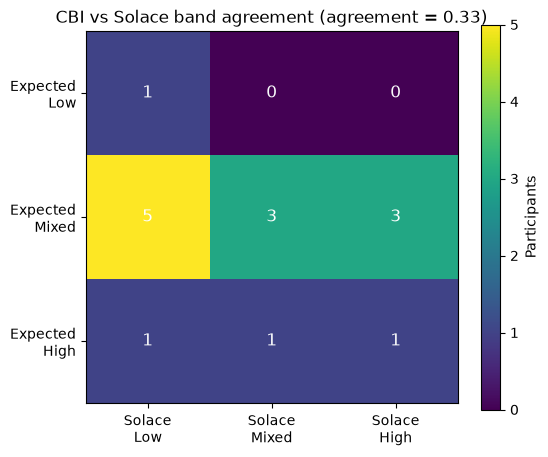

In [42]:
# CBI vs Solace band agreement bar graph
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(agreement_matrix.values)
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels([f"Solace\n{label}" for label in labels])
ax.set_yticklabels([f"Expected\n{label}" for label in labels])
for row in range(agreement_matrix.shape[0]):
    for col in range(agreement_matrix.shape[1]):
        # set count
        count = agreement_matrix.values[row, col]
        # compute colour
        colour = "white" if count > agreement_matrix.values.max() / 2 else "#F9FAFB"
        ax.text(col, row, str(count), ha="center", va="center", color=colour, fontsize=12)
# set title
ax.set_title(f"CBI vs Solace band agreement (agreement = {agreement:.2f})")
plt.colorbar(im, ax=ax, label="Participants")
plt.show()

**Analysis:** 

Because it shows whether the two instruments would put a participant in the same risk category the result that actually reaches a user band agreement is the most decision-relevant evidence the notebook generates. When read in conjunction with the confusion matrix, the overall agreement printed above reveals not only how frequently the bands match but also where and in which direction they diverge. Off-diagonal cells indicate whether Solace tends to place people one band more or less favorably than their burnout score suggests, which is far more informative for a wellbeing tool than a single accuracy number. Similar to the correlation, the agreement should be compared to the number of matched participants on such a tiny sample, any systematic off-diagonal trend is more significant than the headline value. The figures above can be viewed as a shape rather than as discrete statistics since the final portion explicitly visualises the underlying relationship.

## 12 Visualisation

This section provides a clear visual representation of the relationship that the correlation coefficients summarize numerically by plotting the Solace wellbeing score against the CBI burnout score on fixed 0-100 axis. Because it reveals the relationship's form, any grouping, and any individual individuals who defy the predicted downward trend all of which a single coefficient obscures a scatter plot is a correlation's natural complement.

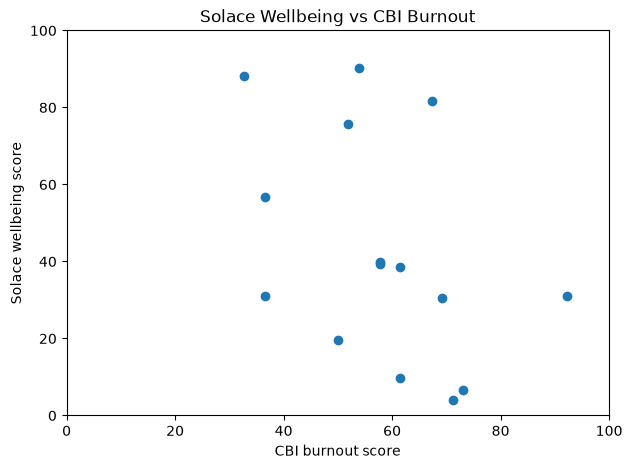

In [43]:
# Solace Wellbeing vs CBI Burnout scatter plot
plt.figure(figsize=(7, 5))
plt.scatter(study_df["cbi_score"], study_df["wellbeing_score"])
plt.xlabel("CBI burnout score")
plt.ylabel("Solace wellbeing score")
plt.title("Solace Wellbeing vs CBI Burnout")
plt.xlim(0, 100)
plt.ylim(0, 100)
plt.show()

**Analysis:** 

Points traveling from the top-left (low burnout, high wellbeing) to the bottom-right (high burnout, low wellbeing) indicate a true inverse link the higher the construct validity, the tighter the downward trend. Additionally, the plot is the fastest way to identify a person who deviates from the trend, such as someone who Solace ranks highly but the CBI evaluates as significantly burned out. This is the kind of case that should be examined separately and reported honestly rather than averaging away. The dispersion is frequently more instructive than the correlation coefficient for a small sample. The conclusion summarises the findings and conclusions of this real-data validation.

## 13 Conclusion

In this notebook, explore the relationship between scores on the questionnaire burnout and Solace wellbeing measures using recordings of participants. Both audio-only and video recordings are supported. One recording per participant is selected and processed through the corresponding application pathway. Pearson and Spearman correlations and band agreement provide preliminary evidence of the relationship between the measures and not proof of clinical validity.

Three pieces of evidence can be extracted from a finished run the direction of any disagreement in the confusion matrix and scatter plot, the overall band agreement example whether the two instruments place people in corresponding risk categories, and the sign and strength of the correlation a definite negative value supports the Solace score as a valid inverse indicator of burnout. This evidence is more relevant to the intended users of the application because it includes recordings in English, Malay, Chinese, and Tamil due to the notebook's multilingual architecture.

The main drawback is sample size a final-year user study only recruits a small number of participants, so the results are real but preliminary precise correlation magnitudes should be reported cautiously and not overinterpreted, while the direction of the relationship and the band agreement are the reliable outcomes. The contribution includes framing the results in this manner the notebook provides an honest, repeatable external-validation process whose findings automatically become more robust when more participants are added, just by rerunning it on the updated responses and recordings. Audio and video use different combinations of signals, so the number of participants evaluated through each pathway should be reported alongside the combined results

## 14 References

[1] T. S. Kristensen, M. Borritz, E. Villadsen, and K. B. Christensen, “The Copenhagen Burnout Inventory: a new tool for the assessment of burnout,” 2005. [Online]. Available: https://doi.org/10.1080/02678370500297720. [Accessed: 1 August 2026].